#  Traditional Machine Learning Classifiers
### Skin Cancer Detection ML Project  |  Colab-Style Notebook
---
> **Models:** SVM (RBF), Linear SVM, Decision Tree, KNN, Logistic Regression  
> **Features:** Flattened pixel values (64×64 grayscale = 4096 features)  
> **Task:** Binary Classification — Benign (0) vs Malignant (1)

---
##  Sections
1. Setup and Library Imports
2. Dataset Loading and Preprocessing
3. Feature Extraction (Pixel Flattening)
   - 3.2 Visualization of Grayscale Images
4. Train/Test Split and Feature Scaling
5. Model Training and Evaluation
6. Confusion Matrices
7. Performance Comparison Table
8. Visual Comparison


---
## 1.  Setup and Library Imports


In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})
print('[OK] All libraries loaded.')


[OK] All libraries loaded.


---
## 2.  Dataset Loading and Preprocessing


In [2]:
import os
import glob
import pandas as pd

# Detect if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Running in Google Colab!')
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Metadata path
    METADATA_PATH = 'HAM10000_metadata.csv'
    if not os.path.exists(METADATA_PATH):
        METADATA_PATH = '/content/HAM10000_metadata.csv'
    
    IMAGES_DIR = '/content/drive/MyDrive'
else:
    # Local path resolution
    wsl_path = os.path.expanduser('~/data/HAM10000_metadata.csv')
    if os.path.exists(wsl_path):
        METADATA_PATH = wsl_path
        IMAGES_DIR    = os.path.expanduser('~/data')
    elif os.path.exists('data/HAM10000_metadata.csv'):
        METADATA_PATH = 'data/HAM10000_metadata.csv'
        IMAGES_DIR    = 'data'
    elif os.path.exists('../data/HAM10000_metadata.csv'):
        METADATA_PATH = '../data/HAM10000_metadata.csv'
        IMAGES_DIR    = '../data'
    else:
        METADATA_PATH = '../data/HAM10000_metadata.csv'
        IMAGES_DIR    = '../data'

print(f'Metadata Path: {METADATA_PATH}')
print(f'Images Directory: {IMAGES_DIR}')

df = pd.read_csv(METADATA_PATH)

image_paths = []
part1_path = os.path.join(IMAGES_DIR, 'HAM10000_images_part_1')
part2_path = os.path.join(IMAGES_DIR, 'HAM10000_images_part_2')

if os.path.exists(part1_path):
    image_paths.extend(glob.glob(os.path.join(part1_path, '*.jpg')))
if os.path.exists(part2_path):
    image_paths.extend(glob.glob(os.path.join(part2_path, '*.jpg')))

if len(image_paths) == 0:
    image_paths.extend(glob.glob(os.path.join(IMAGES_DIR, '*.jpg')))

if len(image_paths) == 0:
    if IN_COLAB and IMAGES_DIR == '/content/drive/MyDrive':
        print('[WARNING] Scanning the entire Google Drive recursively might be very slow!')
    image_paths.extend(glob.glob(os.path.join(IMAGES_DIR, '**', '*.jpg'), recursive=True))

image_path_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}

df['path'] = df['image_id'].map(image_path_dict.get)
df = df.dropna(subset=['path']).reset_index(drop=True)

lesion_danger = {
    'nv': 0, 'mel': 1, 'bkl': 0, 'bcc': 1, 'akiec': 1, 'vasc': 0, 'df': 0
}
df['target'] = df['dx'].map(lesion_danger)

print(f'Dataset ready: {len(df)} samples')
print(f'  Benign    : {(df["target"]==0).sum()}')
print(f'  Malignant : {(df["target"]==1).sum()}')


Metadata Path: /home/shan_ahmedshani/data/HAM10000_metadata.csv
Images Directory: /home/shan_ahmedshani/data
Dataset ready: 10015 samples
  Benign    : 8061
  Malignant : 1954


---
## 3.  Feature Extraction (Pixel Flattening)
We resize each image to **64×64 grayscale** and flatten to a 4096-dim vector.
A sample of **3000 images** is used for manageable training time.


In [3]:
IMG_SIZE   = 64        # resize to 64x64
N_SAMPLES  = 3000      # number of images to sample

sub_df = df.sample(N_SAMPLES, random_state=42).reset_index(drop=True)

features = []
labels   = []

print(f'Preprocessing {N_SAMPLES} images ({IMG_SIZE}×{IMG_SIZE} grayscale)...')

for idx, row in sub_df.iterrows():
    if idx % 500 == 0:
        print(f'  Processed {idx}/{N_SAMPLES}...')
    try:
        img = Image.open(row['path']).convert('L')  # grayscale
        img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.Resampling.LANCZOS)
        features.append(np.array(img, dtype=np.float32).ravel())
        labels.append(row['target'])
    except Exception as e:
        print(f'    [WARN]  Error: {e}')

X = np.array(features)
y = np.array(labels)
print(f'\n[OK] Feature matrix: X.shape={X.shape}, y.shape={y.shape}')


Preprocessing 3000 images (64×64 grayscale)...
  Processed 0/3000...
  Processed 500/3000...
  Processed 1000/3000...
  Processed 1500/3000...
  Processed 2000/3000...
  Processed 2500/3000...

[OK] Feature matrix: X.shape=(3000, 4096), y.shape=(3000,)


### 3.2  Visualization of Grayscale Images
Here we visualize a sample of the preprocessed 64x64 grayscale images after flattening.


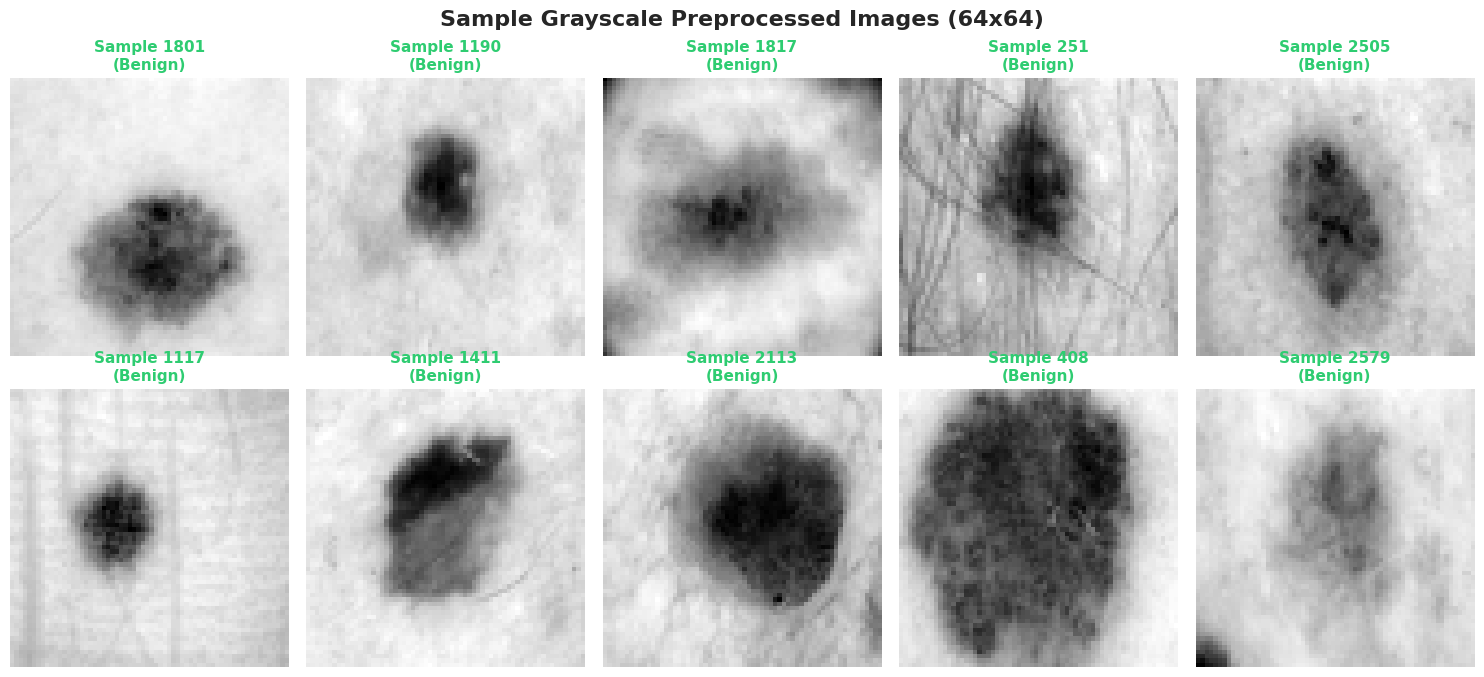

In [4]:
# Select 10 random images
np.random.seed(42)
sample_indices = np.random.choice(len(X), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Sample Grayscale Preprocessed Images (64x64)', fontsize=16, fontweight='bold')

for i, idx in enumerate(sample_indices):
    ax = axes[i // 5, i % 5]
    # Reshape the flattened 4096 vector back to 64x64
    img_gray = X[idx].reshape(64, 64)
    ax.imshow(img_gray, cmap='gray')
    
    label = 'Malignant' if y[idx] == 1 else 'Benign'
    color = '#e74c3c' if y[idx] == 1 else '#2ecc71'
    ax.set_title(f"Sample {idx}\n({label})", color=color, fontweight='bold', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()


---
## 4. [CUT] Train/Test Split and Feature Scaling


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('[OK] Features scaled with StandardScaler')


Train: 2400 samples
Test : 600 samples
[OK] Features scaled with StandardScaler


---
## 5.  Model Training and Evaluation


In [6]:
results = {}

def evaluate_model(name, clf, X_tr, X_te, y_tr, y_te, scale=True):
    """Train, predict, collect metrics."""
    Xtr = X_tr if scale else X_train
    Xte = X_te if scale else X_test

    print(f'   Training {name}...')
    clf.fit(Xtr, y_tr)
    preds = clf.predict(Xte)

    rep = classification_report(y_te, preds, output_dict=True, zero_division=0)
    acc = accuracy_score(y_te, preds)

    results[name] = {
        'Accuracy'    : round(acc, 4),
        'B_Precision' : round(rep['0']['precision'], 4),
        'B_Recall'    : round(rep['0']['recall'], 4),
        'B_F1'        : round(rep['0']['f1-score'], 4),
        'M_Precision' : round(rep['1']['precision'], 4),
        'M_Recall'    : round(rep['1']['recall'], 4),
        'M_F1'        : round(rep['1']['f1-score'], 4),
        'clf'         : clf,
        'preds'       : preds,
    }
    print(f'     Accuracy: {acc:.4f}')
    print(classification_report(y_te, preds, target_names=['Benign','Malignant'], zero_division=0))
    print('-' * 60)

print('=' * 60)
print('  MODEL TRAINING AND EVALUATION')
print('=' * 60)

evaluate_model('SVM (RBF)',        SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True),
               X_train_sc, X_test_sc, y_train, y_test)
evaluate_model('Linear SVM',       SVC(kernel='linear', C=1.0, class_weight='balanced', probability=True),
               X_train_sc, X_test_sc, y_train, y_test)
evaluate_model('Decision Tree',    DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
               X_train_sc, X_test_sc, y_train, y_test)
evaluate_model('KNN',              KNeighborsClassifier(n_neighbors=5),
               X_train_sc, X_test_sc, y_train, y_test)
evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'),
               X_train_sc, X_test_sc, y_train, y_test)


  MODEL TRAINING AND EVALUATION
   Training SVM (RBF)...
     Accuracy: 0.7233
              precision    recall  f1-score   support

      Benign       0.89      0.75      0.81       483
   Malignant       0.37      0.60      0.46       117

    accuracy                           0.72       600
   macro avg       0.63      0.68      0.64       600
weighted avg       0.79      0.72      0.74       600

------------------------------------------------------------
   Training Linear SVM...
     Accuracy: 0.7567
              precision    recall  f1-score   support

      Benign       0.84      0.86      0.85       483
   Malignant       0.36      0.33      0.35       117

    accuracy                           0.76       600
   macro avg       0.60      0.60      0.60       600
weighted avg       0.75      0.76      0.75       600

------------------------------------------------------------
   Training Decision Tree...
     Accuracy: 0.6867
              precision    recall  f1-score   

---
## 6.  Confusion Matrices


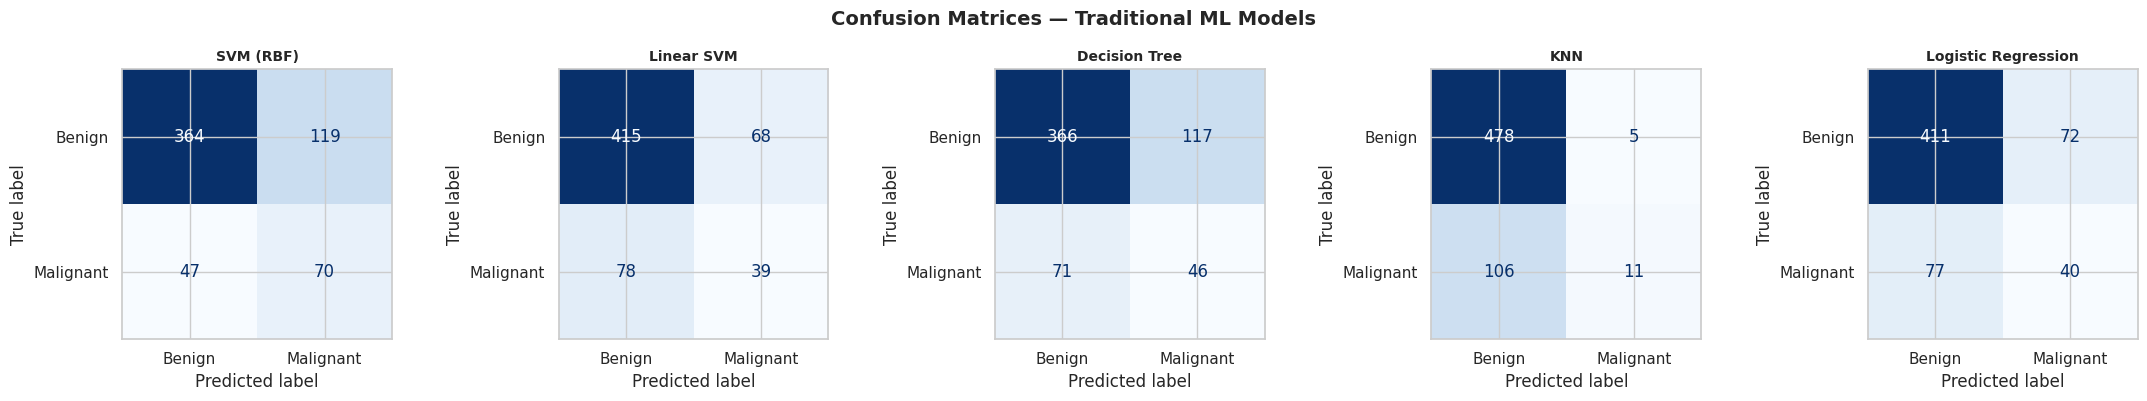

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
model_names = list(results.keys())

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, results[name]['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Benign', 'Malignant'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — Traditional ML Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7.  Performance Comparison Table


In [8]:
# Build summary dataframe
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        'Model'       : name,
        'Accuracy'    : r['Accuracy'],
        'B_Precision' : r['B_Precision'],
        'B_Recall'    : r['B_Recall'],
        'B_F1'        : r['B_F1'],
        'M_Precision' : r['M_Precision'],
        'M_Recall'    : r['M_Recall'],
        'M_F1'        : r['M_F1'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('Performance Summary Table:')
print(summary_df.to_string())
summary_df


Performance Summary Table:
                     Accuracy  B_Precision  B_Recall    B_F1  M_Precision  M_Recall    M_F1
Model                                                                                      
SVM (RBF)              0.7233       0.8856    0.7536  0.8143       0.3704    0.5983  0.4575
Linear SVM             0.7567       0.8418    0.8592  0.8504       0.3645    0.3333  0.3482
Decision Tree          0.6867       0.8375    0.7578  0.7957       0.2822    0.3932  0.3286
KNN                    0.8150       0.8185    0.9896  0.8960       0.6875    0.0940  0.1654
Logistic Regression    0.7517       0.8422    0.8509  0.8465       0.3571    0.3419  0.3493


,Accuracy,B_Precision,B_Recall,B_F1,M_Precision,M_Recall,M_F1
Model,,,,,,,
SVM (RBF),0.7233,0.8856,0.7536,0.8143,0.3704,0.5983,0.4575
Linear SVM,0.7567,0.8418,0.8592,0.8504,0.3645,0.3333,0.3482
Decision Tree,0.6867,0.8375,0.7578,0.7957,0.2822,0.3932,0.3286
KNN,0.8150,0.8185,0.9896,0.8960,0.6875,0.0940,0.1654
Logistic Regression,0.7517,0.8422,0.8509,0.8465,0.3571,0.3419,0.3493


---
## 8.  Visual Comparison


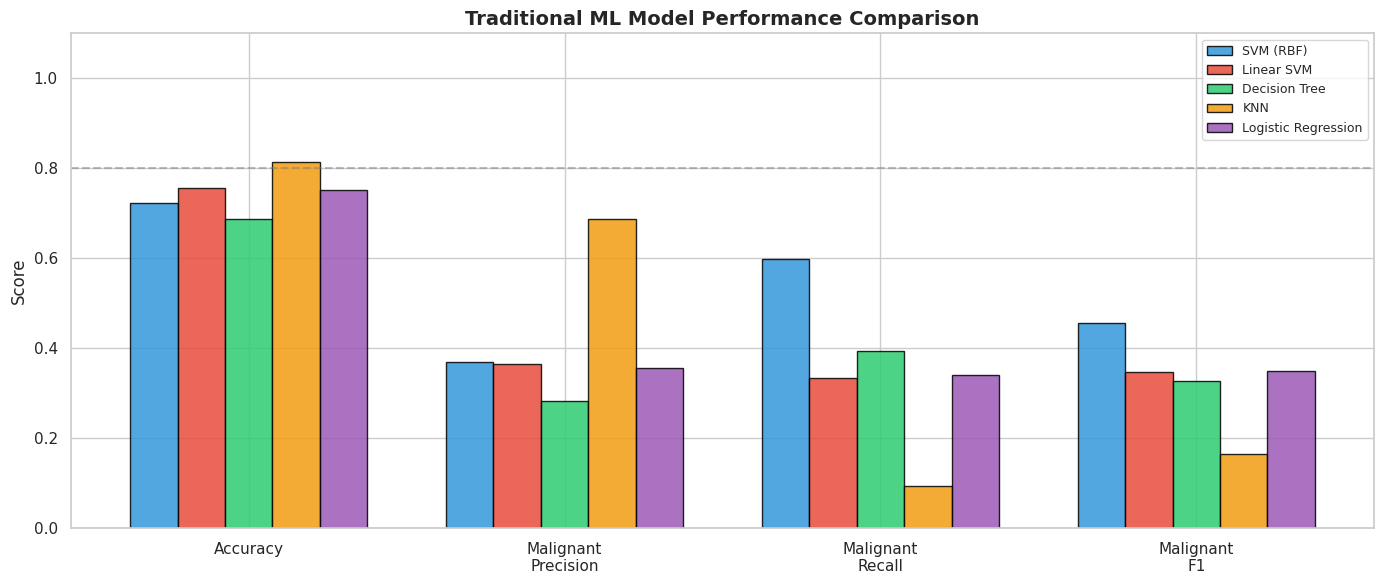

In [9]:
metrics = ['Accuracy', 'M_Precision', 'M_Recall', 'M_F1']
labels_display = ['Accuracy', 'Malignant\nPrecision', 'Malignant\nRecall', 'Malignant\nF1']

x = np.arange(len(metrics))
width = 0.15
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85, edgecolor='black')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels_display, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Traditional ML Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 baseline')

plt.tight_layout()
plt.show()
